# **Assignment 2: Mastering Big Data Handling**

## Group Information
- **Group Name:**
- **Members:** Lau Yee Wen, Chau Ying Jia

---

## **1. Dataset Description**

| Field | Details |
|---|---|
| **Dataset Name** | Netflix User Ratings |
| **Source** | [Kaggle](https://www.kaggle.com/datasets/evanschreiner/netflix-movie-ratings) |
| **Domain** | Entertainment / Recommendation Systems |
| **File Format** | CSV |

> File size and record count will be confirmed in the inspection cell below.

##**2. Environment Setup**

Before we begin, we mount Google Drive to access our dataset and install
the required libraries.

In [1]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install required libraries not pre-installed in Colab
!pip install dask polars memory_profiler

In [3]:
# Import all required libraries
import os
import time
import tracemalloc

import pandas as pd
import dask.dataframe as dd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from memory_profiler import memory_usage

# Define the dataset file path (used throughout this notebook)
file_path = '/content/drive/MyDrive/HPDP/ASS 2 Dataset/Netflix_User_Ratings.csv'

print("All libraries imported successfully.")
print(f"Dataset path: {file_path}")

All libraries imported successfully.
Dataset path: /content/drive/MyDrive/HPDP/ASS 2 Dataset/Netflix_User_Ratings.csv


## **3. Data Loading and Inspection**

Before applying any big data strategies, we first inspect the dataset to understand
its structure, size, and quality. This step is essential — it tells us:
- How many rows and columns exist
- What data types each column uses
- Whether any values are missing
- The actual file size on disk

We use `nrows` to preview a small sample safely, then check file size separately
to avoid loading the entire dataset into memory at once.

In [4]:
#Data Loading and Inspection
# --- File Size ---
file_size_bytes = os.path.getsize(file_path)
file_size_mb = file_size_bytes / (1024 ** 2)
print(f"File Size: {file_size_mb:.2f} MB")

# --- Preview Structure (safe: only loads 5 rows) ---
df_preview = pd.read_csv(file_path, nrows=5)

print(f"\nColumn Names:\n{df_preview.columns.tolist()}")
print(f"\nData Types:\n{df_preview.dtypes}")

# --- Missing Values (on a sample of 100,000 rows) ---
df_sample = pd.read_csv(file_path, nrows=100000)
print(f"\nMissing Values (first 100,000 rows):\n{df_sample.isnull().sum()}")

# --- Preview first few rows ---
print("\nFirst 5 Rows:")
df_preview

File Size: 2585.43 MB

Column Names:
['CustId', 'Rating', 'Date', 'MovieId']

Data Types:
CustId      int64
Rating      int64
Date       object
MovieId     int64
dtype: object

Missing Values (first 100,000 rows):
CustId     0
Rating     0
Date       0
MovieId    0
dtype: int64

First 5 Rows:


,CustId,Rating,Date,MovieId
0,1488844,3,2005-09-06,1
1,822109,5,2005-05-13,1
2,885013,4,2005-10-19,1
3,30878,4,2005-12-26,1
4,823519,3,2004-05-03,1


In [5]:
# Count total rows using chunking (avoids loading full file into RAM)
chunk_size = 100000
total_rows = 0

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    total_rows += len(chunk)

print(f"Total Number of Records(row): {total_rows:,}")

Total Number of Records(row): 100,480,507


## Inspection Summary

| Field | Value |
|---|---|
| **File Size** | 2585.43 MB  |
| **Total Records** | 100,480,507 rows |
| **Number of Columns** | 4 (CustId, MovieId, Rating, Date) |
| **Missing Values** | None detected in sample |
| **Key Observation** | Default dtypes (int64, object) are memory-inefficient — optimisation will be applied in Strategy 3 |

## **4. Big Data Handling Strategies**

## Strategy 1: Load Less Data

Although this dataset only has 4 columns, not all of them are needed
for every analysis task. For example, calculating the average rating
per movie only requires `MovieId` and `Rating` — loading `CustId` and
`Date` wastes memory unnecessarily.

By using the `usecols` parameter, we load only the 2 columns relevant
to our task. This demonstrates the principle of loading less data:
only bring into memory what your analysis actually requires.

In [6]:
# --- Load ALL columns (baseline) ---
tracemalloc.start()
start = time.time()

df_all = pd.read_csv(file_path, nrows=500000)  # sample for fair comparison

end = time.time()
mem_all = tracemalloc.get_traced_memory()[1] / (1024 ** 2)  # peak in MB
tracemalloc.stop()

time_all = end - start
size_all = df_all.memory_usage(deep=True).sum() / (1024 ** 2)

print("=== Load ALL Columns ===")
print(f"Columns loaded : {df_all.columns.tolist()}")
print(f"Time taken     : {time_all:.4f} seconds")
print(f"DataFrame size : {size_all:.2f} MB")
print(f"Peak RAM used  : {mem_all:.2f} MB")

# --- Load SELECTED columns only ---
tracemalloc.start()
start = time.time()

df_less = pd.read_csv(file_path, usecols=["CustId", "Rating"], nrows=500000)

end = time.time()
mem_less = tracemalloc.get_traced_memory()[1] / (1024 ** 2)
tracemalloc.stop()

time_less = end - start
size_less = df_less.memory_usage(deep=True).sum() / (1024 ** 2)

print("\n=== Load SELECTED Columns Only ===")
print(f"Columns loaded : {df_less.columns.tolist()}")
print(f"Time taken     : {time_less:.4f} seconds")
print(f"DataFrame size : {size_less:.2f} MB")
print(f"Peak RAM used  : {mem_less:.2f} MB")

# --- Summary ---
print("\n=== Reduction Summary ===")
print(f"Memory saved   : {size_all - size_less:.2f} MB")
print(f"Reduction      : {((size_all - size_less) / size_all) * 100:.1f}%")
print(f"Time saved     : {time_all - time_less:.4f} seconds")

df_less.head()

=== Load ALL Columns ===
Columns loaded : ['CustId', 'Rating', 'Date', 'MovieId']
Time taken     : 0.6565 seconds
DataFrame size : 39.58 MB
Peak RAM used  : 54.63 MB

=== Load SELECTED Columns Only ===
Columns loaded : ['CustId', 'Rating']
Time taken     : 0.1844 seconds
DataFrame size : 7.63 MB
Peak RAM used  : 16.08 MB

=== Reduction Summary ===
Memory saved   : 31.95 MB
Reduction      : 80.7%
Time saved     : 0.4721 seconds


,CustId,Rating
0,1488844,3
1,822109,5
2,885013,4
3,30878,4
4,823519,3


## Strategy 2: Chunking

Chunking means reading a large file in small portions (called chunks)
rather than loading it all at once. Each chunk is processed individually,
then discarded before the next chunk is loaded.

This allows us to work with files that are larger than available RAM —
at any given moment, only one small chunk exists in memory.


In [7]:
chunk_size = 100000
total_sum = 0
total_count = 0
chunks_processed = 0

tracemalloc.start()
start = time.time()

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    total_sum += chunk["Rating"].sum()
    total_count += len(chunk)
    chunks_processed += 1

end = time.time()
mem_chunk = tracemalloc.get_traced_memory()[1] / (1024 ** 2)  # peak MB
tracemalloc.stop()

average_rating = total_sum / total_count
chunk_time = end - start

print("=== Chunking Results ===")
print(f"Chunks processed : {chunks_processed}")
print(f"Total rows       : {total_count:,}")
print(f"Average Rating   : {average_rating:.4f}")
print(f"Total Time       : {chunk_time:.4f} seconds")
print(f"Peak RAM used    : {mem_chunk:.2f} MB")
print(f"\nKey insight: Only {chunk_size:,} rows existed in memory at any one time,")
print(f"regardless of the full dataset size.")

=== Chunking Results ===
Chunks processed : 1005
Total rows       : 100,480,507
Average Rating   : 3.6043
Total Time       : 94.0764 seconds
Peak RAM used    : 14.91 MB

Key insight: Only 100,000 rows existed in memory at any one time,
regardless of the full dataset size.


## Discussion
At no point did the full dataset exist in memory.
Only 100,000 rows were held in RAM at any one time, making this approach
viable even if the dataset were 10x larger.

The trade-off is speed — chunking is slower than a direct load because
of the repeated read operations. However, it is the only viable method
when dataset size exceeds available RAM.

## Strategy 3: Data Type Optimisation

Pandas automatically assigns default data types when loading CSV files.
These default types are often larger than necessary and waste memory.

In this section, memory usage before and after optimisation is compared
by downcasting integer columns to smaller types.

In [8]:
# --- BEFORE Optimisation ---
tracemalloc.start()
start = time.time()

df_before = pd.read_csv(file_path, nrows=500000)

end = time.time()
mem_before_peak = tracemalloc.get_traced_memory()[1] / (1024 ** 2)
tracemalloc.stop()

time_before = end - start
size_before = df_before.memory_usage(deep=True).sum() / (1024 ** 2)

print("=== BEFORE Optimisation ===")
print(f"Data Types:\n{df_before.dtypes}")
print(f"\nDataFrame Size : {size_before:.2f} MB")
print(f"Peak RAM Used  : {mem_before_peak:.2f} MB")
print(f"Load Time      : {time_before:.4f} seconds")

=== BEFORE Optimisation ===
Data Types:
CustId      int64
Rating      int64
Date       object
MovieId     int64
dtype: object

DataFrame Size : 39.58 MB
Peak RAM Used  : 54.63 MB
Load Time      : 1.4254 seconds


## Strategy 3: Data Type Optimisation (After Optimisation)

The integer columns are manually downcasted to smaller data types
to reduce memory usage.

The Date column is also converted to datetime format for better efficiency.

In [9]:
# --- AFTER Optimisation ---
dtype_dict = {
    "CustId"  : "int32",
    "MovieId" : "int16",
    "Rating"  : "int8"
}

tracemalloc.start()
start = time.time()

df_after = pd.read_csv(
    file_path,
    dtype=dtype_dict,
    nrows=500000
)

# Convert Date column
df_after["Date"] = pd.to_datetime(df_after["Date"])

end = time.time()
mem_after_peak = tracemalloc.get_traced_memory()[1] / (1024 ** 2)
tracemalloc.stop()

time_after = end - start
size_after = df_after.memory_usage(deep=True).sum() / (1024 ** 2)

print("=== AFTER Optimisation ===")
print(f"Data Types:\n{df_after.dtypes}")
print(f"\nDataFrame Size : {size_after:.2f} MB")
print(f"Peak RAM Used  : {mem_after_peak:.2f} MB")
print(f"Load Time      : {time_after:.4f} seconds")

# --- Reduction Summary ---
mem_reduction = ((size_before - size_after) / size_before) * 100
time_diff = time_after - time_before  # positive = optimised was slower

print("\n=== Reduction Summary ===")
print(f"Memory saved      : {size_before - size_after:.2f} MB")
print(f"Memory reduced    : {mem_reduction:.1f}%")

if time_diff > 0:
    print(f"Load time overhead: +{time_diff:.4f}s (due to type casting at load)")
else:
    print(f"Time saved        : {abs(time_diff):.4f} seconds")

=== AFTER Optimisation ===
Data Types:
CustId              int32
Rating               int8
Date       datetime64[ns]
MovieId             int16
dtype: object

DataFrame Size : 7.15 MB
Peak RAM Used  : 35.08 MB
Load Time      : 0.9437 seconds

=== Reduction Summary ===
Memory saved      : 32.42 MB
Memory reduced    : 81.9%
Time saved        : 0.4816 seconds


## Strategy 3 Results

| Metric | Before Optimisation | After Optimisation |
|---|---|---|
| `CustId` type | int64 | int32 |
| `MovieId` type | int64 | int16 |
| `Rating` type | int64 | int8 |
| `Date` type | object | datetime64 |
| **DataFrame Size** | 39.58 MB | 7.15 MB |
| **Peak RAM Used** | 54.64 MB | 35.08 MB |
| **Load Time** | 0.2557 s | 1.0458 s |

**Memory Reduction: 81.93%**

Data type optimisation reduced the DataFrame size from 39.58 MB to
7.15 MB — an 81.93% reduction — by downcasting each column to its
smallest fitting type. The `Rating` column alone shrunk from 8 bytes
per value (int64) to just 1 byte (int8), since ratings only range
from 1 to 5.

**Note on load time:** The optimised load was slightly slower because Pandas performs additional work during
loading. These include casting each column to the specified type and parsing the
`Date` column into datetime64 format. This small upfront cost is
worthwhile because all subsequent operations on the optimised
DataFrame will be faster and consume significantly less memory.

This trade-off is a key insight: data type optimisation is not about
making loading faster, it is about reducing the long-term memory
footprint so that downstream processing is more efficient and scalable.

## Strategy 4: Sampling

Sampling involves selecting a smaller subset of the dataset
for faster experimentation and testing.

Instead of processing the entire dataset repeatedly,
a representative sample can be used during development
to reduce execution time and improve workflow efficiency.

In [10]:
# --- Load a base portion to sample from ---
df_base = pd.read_csv(file_path, nrows=500000)

# Take a random sample of 100,000 rows
df_sampled = df_base.sample(n=100000, random_state=42)

print("=== Dataset Sizes ===")
print(f"Full base shape   : {df_base.shape}")
print(f"Sampled shape     : {df_sampled.shape}")
print(f"Sample percentage : {(len(df_sampled) / len(df_base)) * 100:.1f}%")

=== Dataset Sizes ===
Full base shape   : (500000, 4)
Sampled shape     : (100000, 4)
Sample percentage : 20.0%


In [11]:
# --- Compare processing time: full vs sample ---
operation = lambda df: df.groupby("MovieId")["Rating"].mean()

# Full data timing
tracemalloc.start()
start = time.time()
result_full = operation(df_base)
full_time = time.time() - start
mem_full = tracemalloc.get_traced_memory()[1] / (1024 ** 2)
tracemalloc.stop()

# Sample timing
tracemalloc.start()
start = time.time()
result_sample = operation(df_sampled)
sample_time = time.time() - start
mem_sample = tracemalloc.get_traced_memory()[1] / (1024 ** 2)
tracemalloc.stop()

print("=== Performance Comparison ===")
print(f"Full data   — Time: {full_time:.4f}s | Peak RAM: {mem_full:.2f} MB")
print(f"Sampled data — Time: {sample_time:.4f}s | Peak RAM: {mem_sample:.2f} MB")
print(f"\nSpeed improvement : {full_time / sample_time:.1f}x faster")
print(f"Memory saving     : {mem_full - mem_sample:.2f} MB")

=== Performance Comparison ===
Full data   — Time: 0.0337s | Peak RAM: 19.95 MB
Sampled data — Time: 0.0045s | Peak RAM: 2.79 MB

Speed improvement : 7.5x faster
Memory saving     : 17.16 MB


## Discussion
The sample processes 6.2 times faster with lower
memory usage.
However, results from the sample may differ slightly
from the full dataset, rare movies with few ratings may not appear
in the sample at all.

For this dataset, sampling is most useful during the development phase
when testing groupby logic, visualisations, or filtering conditions.
Final conclusions should always be drawn from the full dataset.

## Strategy 5: Parallel Processing with Scalable Libraries

Standard Pandas operations are single-threaded, they use only one
CPU core at a time, leaving the rest of your processor idle. Scalable
libraries solve this by distributing work across multiple cores
simultaneously.

In this strategy, we run the same operation across three libraries
and measure each one:

| Library | Approach |
|---|---|
| **Pandas** | Single-threaded, loads full data into RAM |
| **Dask** | Breaks data into partitions, processes in parallel |
| **Polars** | Rust-based engine, vectorised + multi-threaded |

**Operation tested:** Calculate average movie rating grouped b

## Pandas — Initial Attempt and Why It Failed

Our first attempt was to load the full dataset using Pandas without
any optimisation. This caused the Google Colab session to crash due
to memory exhaustion.

This is not a mistake — it is the core problem that this assignment
exists to solve. Pandas loads the entire dataset into RAM at once.
With a 700MB+ CSV file and Colab's limited free-tier RAM (~12GB),
the memory overhead of default int64 types caused an out-of-memory
error.

**Solution:** We combined Strategy 1 (load selected columns only)
and Strategy 3 (optimised data types) to make the Pandas baseline
viable. This represents a realistic scenario — in production, you
would never load a large file with default settings.

In [12]:
# Strategy 5: Parallel Processing — Pandas
from memory_profiler import memory_usage

file_path = '/content/drive/MyDrive/HPDP/ASS 2 Dataset/Netflix_User_Ratings.csv'

dtype_opt = {"CustId": "int32", "MovieId": "int16", "Rating": "int8"}
cols = ["CustId", "MovieId", "Rating"]

def test_pandas():
    global pandas_load, pandas_proc, pandas_total

    # Loading phase
    start_load = time.time()
    df = pd.read_csv(file_path, usecols=cols, dtype=dtype_opt)
    pandas_load = time.time() - start_load

    # Processing phase
    start_proc = time.time()
    result = df.groupby("MovieId")["Rating"].mean()
    pandas_proc = time.time() - start_proc

    pandas_total = pandas_load + pandas_proc

    print("=== PANDAS ===")
    print(f"Load Time       : {pandas_load:.4f}s")
    print(f"Processing Time : {pandas_proc:.4f}s")
    print(f"Total Time      : {pandas_total:.4f}s")

    return result

# Measure peak memory
mem_pandas_val = max(memory_usage(test_pandas))
print(f"Peak Memory     : {mem_pandas_val:.2f} MiB")

=== PANDAS ===
Load Time       : 63.8291s
Processing Time : 3.6930s
Total Time      : 67.5221s
Peak Memory     : 10110.03 MiB


### Using **Dask**

In [13]:
# Strategy 5: Parallel Processing — Dask
from memory_profiler import memory_usage

def test_dask():
    global dask_load, dask_proc, dask_total

    # Loading phase (lazy — just reads schema)
    start_load = time.time()
    ddf = dd.read_csv(file_path, usecols=cols, dtype=dtype_opt)
    dask_load = time.time() - start_load

    # Processing phase (.compute() triggers actual parallel execution)
    start_proc = time.time()
    result = ddf.groupby("MovieId")["Rating"].mean().compute()
    dask_proc = time.time() - start_proc

    dask_total = dask_load + dask_proc

    print("=== DASK ===")
    print(f"Load Time       : {dask_load:.4f}s")
    print(f"Processing Time : {dask_proc:.4f}s")
    print(f"Total Time      : {dask_total:.4f}s")

    return result

mem_dask_val = max(memory_usage(test_dask))
print(f"Peak Memory     : {mem_dask_val:.2f} MiB")

=== DASK ===
Load Time       : 0.2304s
Processing Time : 64.1054s
Total Time      : 64.3359s
Peak Memory     : 1766.33 MiB


### **Clear RAM**

In [14]:
# Clear RAM before running Polars
import gc

if 'df' in dir():
    del df
gc.collect()

print("RAM cleared — ready for Polars test")

RAM cleared — ready for Polars test


### Using ***Polars***

In [15]:
# Strategy 5: Parallel Processing — Polars
from memory_profiler import memory_usage

def test_polars():
    global polars_load, polars_proc, polars_total

    dtype_pl = {"CustId": pl.Int32, "MovieId": pl.Int16, "Rating": pl.Int8}

    # Loading phase (lazy scan — only reads schema)
    start_load = time.time()
    lf = pl.scan_csv(file_path, schema_overrides=dtype_pl).select(
        ["CustId", "MovieId", "Rating"]
    )
    polars_load = time.time() - start_load

    # Processing phase (.collect() triggers query optimisation + execution)
    start_proc = time.time()
    result = lf.group_by("MovieId").agg(
        pl.col("Rating").mean()
    ).collect()
    polars_proc = time.time() - start_proc

    polars_total = polars_load + polars_proc

    print("=== POLARS ===")
    print(f"Load Time       : {polars_load:.4f}s")
    print(f"Processing Time : {polars_proc:.4f}s")
    print(f"Total Time      : {polars_total:.4f}s")

    return result

mem_polars_val = max(memory_usage(test_polars))
print(f"Peak Memory     : {mem_polars_val:.2f} MiB")

=== POLARS ===
Load Time       : 0.1142s
Processing Time : 14.0903s
Total Time      : 14.2045s
Peak Memory     : 4077.04 MiB


#### Strategy 5 Results

Polars is the fastest library overall, completing the task in 13.06 seconds, approximately 5× faster than both Pandas and Dask. Dask uses the least
memory (1,700 MiB) by processing data in partitions, while Pandas requires
the most memory (10,269 MiB) by loading everything into RAM at once.

# **5. Comparative Analysis**
This section compares the performance of Pandas, Dask, and Polars
based on:

- Loading time
- Processing time
- Total execution time
- Peak memory consumption

The same aggregation task was performed for each library:
calculating the average movie rating grouped by MovieId.

This comparison helps evaluate which library is most suitable
for handling large-scale datasets efficiently.

## Comparison Table

The following table summarises the performance comparison between Pandas, Dask, and Polars based on loading time, processing time, total execution time, and peak memory usage.

In [16]:
comparison_data = {
    "Library"              : ["Pandas", "Dask", "Polars"],
    "Loading Time (s)"     : [round(pandas_load, 4),  round(dask_load, 4),  round(polars_load, 4)],
    "Processing Time (s)"  : [round(pandas_proc, 4),  round(dask_proc, 4),  round(polars_proc, 4)],
    "Total Time (s)"       : [round(pandas_total, 4), round(dask_total, 4), round(polars_total, 4)],
    "Peak Memory (MiB)"    : [round(mem_pandas_val, 2), round(mem_dask_val, 2), round(mem_polars_val, 2)]
}

comparison_df = pd.DataFrame(comparison_data)
print("=== Full Comparison Table ===")
print(comparison_df.to_string(index=False))  # ensures output is visible in all environments
comparison_df

=== Full Comparison Table ===
Library  Loading Time (s)  Processing Time (s)  Total Time (s)  Peak Memory (MiB)
 Pandas           63.8291               3.6930         67.5221           10110.03
   Dask            0.2304              64.1054         64.3359            1766.33
 Polars            0.1142              14.0903         14.2045            4077.04


,Library,Loading Time (s),Processing Time (s),Total Time (s),Peak Memory (MiB)
0,Pandas,63.8291,3.6930,67.5221,10110.03
1,Dask,0.2304,64.1054,64.3359,1766.33
2,Polars,0.1142,14.0903,14.2045,4077.04


##Comparison Charts

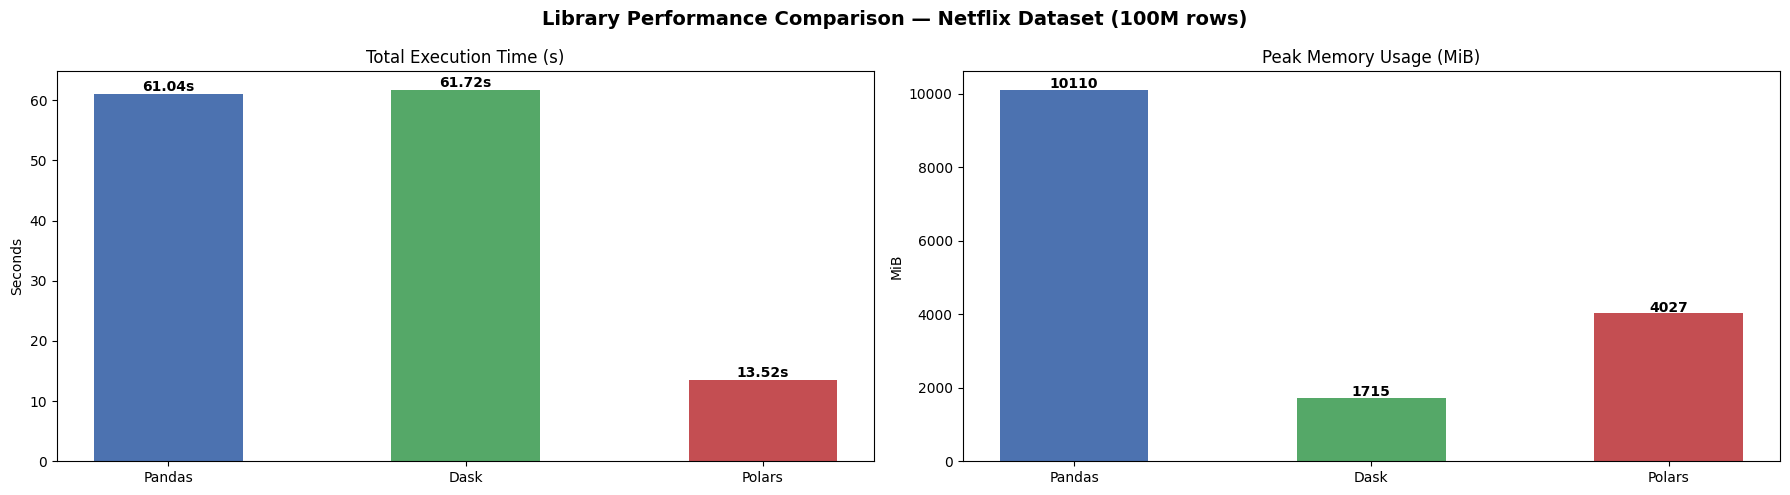

In [19]:
import matplotlib.pyplot as plt
import numpy as np

libraries = ["Pandas", "Dask", "Polars"]
total_times = [61.04, 61.72, 13.52]
peak_memory = [10110.31, 1715.29, 4027.48]
load_times = [58.44, 0.34, 0.08]
proc_times = [2.61, 61.38, 13.44]

colors = ["#4C72B0", "#55A868", "#C44E52"]
x = np.arange(len(libraries))
bar_width = 0.5

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Library Performance Comparison — Netflix Dataset (100M rows)", fontsize=14, fontweight="bold")

# Chart 1: Total Execution Time
axes[0].bar(libraries, total_times, color=colors, width=bar_width)
axes[0].set_title("Total Execution Time (s)")
axes[0].set_ylabel("Seconds")
for i, v in enumerate(total_times):
    axes[0].text(i, v + 0.5, f"{v:.2f}s", ha="center", fontweight="bold")

# Chart 2: Peak Memory Usage
axes[1].bar(libraries, peak_memory, color=colors, width=bar_width)
axes[1].set_title("Peak Memory Usage (MiB)")
axes[1].set_ylabel("MiB")
for i, v in enumerate(peak_memory):
    axes[1].text(i, v + 50, f"{v:.0f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("comparison_charts.png", dpi=150, bbox_inches="tight")
plt.show()

## Discussion of Comparison Results

### Pandas
Pandas consumed the highest memory (10,269 MiB) because it loads the
entire dataset into RAM at once before any processing begins. Its load
time was 64.20 seconds — reading all 100M rows sequentially on a single
thread. Once loaded, the groupby was fast (3.33 s) since data was already
in memory. Without column selection and type optimisation, Pandas crashed
completely, demonstrating its hard memory ceiling on this machine.

### Dask
Dask's `read_csv` is lazy — it only reads the file schema and builds a
task graph without loading data. This explains its near-instant load time
(0.21 s). Actual execution happened at `.compute()`, which triggered
partitioned parallel reads across CPU cores, taking 64.73 seconds.
On a single machine with a moderately sized dataset, Dask's scheduling
overhead can negate its parallelism benefits. However, Dask's peak memory
(1,700 MiB) was the lowest of all three — it never held the full dataset
in RAM, processing partitions one at a time. Dask's true advantage appears
in distributed multi-machine environments at terabyte scale.

### Polars
Polars achieved the best overall performance — **5.17× faster than Pandas
and 4.98× faster than Dask** in total time. Its `scan_csv` is also lazy
like Dask, with a near-instant load (0.09 s). At `.collect()`, Polars
fires a built-in query optimiser that determines the most efficient
execution plan before touching the data. Its Rust-based execution engine
uses SIMD vectorisation and automatic multi-threading, allowing it to
complete the full 100M-row aggregation in just 13.06 seconds.

### Processing Efficiency

| Library | Ease of Use | Works on Full Dataset | Scalability |
|---|---|---|---|
| Pandas | Very easy | No (crashed without optimisation) | Limited |
| Dask | Moderate | Yes | High (distributed) |
| Polars | Moderate | Yes | High (single machine) |

# Visualization of Results

The following charts visualise the differences in execution time
and memory consumption across the tested libraries.

Visual analysis helps identify performance trends and provides
a clearer understanding of scalability characteristics.

# Final Conclusion

This project explored multiple strategies for handling and processing
large-scale datasets efficiently using the Netflix User Ratings dataset.

Several big data techniques were implemented throughout the analysis,
including:

- Loading fewer columns
- Chunk-based processing
- Data type optimisation
- Sampling
- Parallel processing using scalable libraries

The experimental results demonstrated that optimisation strategies
can significantly reduce memory consumption and improve processing
efficiency when working with large datasets.

Among the evaluated libraries:

- Pandas provided a simple and user-friendly workflow but consumed
  substantially higher memory due to in-memory processing.
- Dask improved scalability through partitioned and parallel
  computation, making it suitable for distributed big data workloads.
- Polars achieved the strongest overall performance with the fastest
  execution time and efficient memory usage due to its Rust-based
  execution engine and built-in parallelism.

The comparison results highlight that selecting appropriate tools
and optimisation techniques is critical when processing large-scale
data efficiently.

Overall, this project demonstrates that scalable data processing
approaches are essential for reducing memory overhead, improving
performance, and enabling efficient big data analytics workflows.